# tmp — may25

**Motivation**: scratch notebook <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_RetinaV1'))
from figures.convergence import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

In [3]:
a = 'Kyoto16-bw_m(g0+logi,p1)_t(16×(1,1))_b(8,8)_k(128,512)'
b = 'b200-ep800-lr(0.002)_temp(0.01:0.5)_gr(1000)_(2025_05_02,21:16)'
tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

800

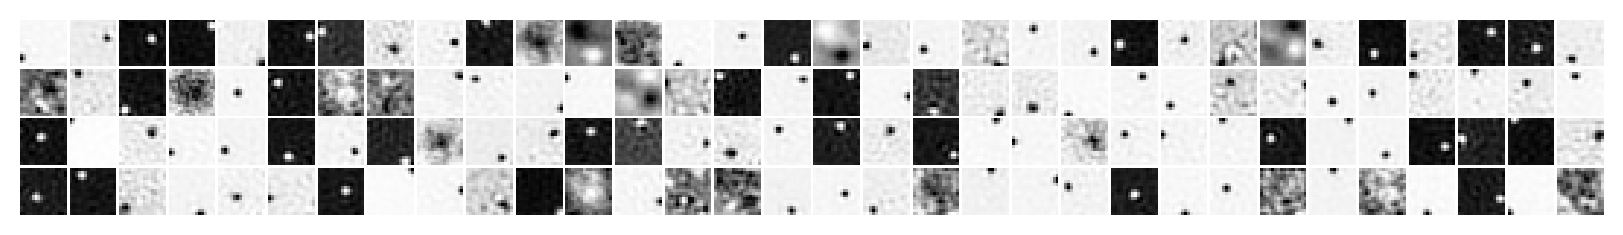

In [134]:
tr.model.show();

In [3]:
a = 'ImageNet32_m(g0+logi,p1)_t(16+64×(1,1))_b(128,96)_k(256,2048)'
b= 'fisher-xi-debug_b200-ep40-lr(0.0005)_temp(0.01:0.5)_gr(1000)_(2025_04_23,12:43)'
tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

40

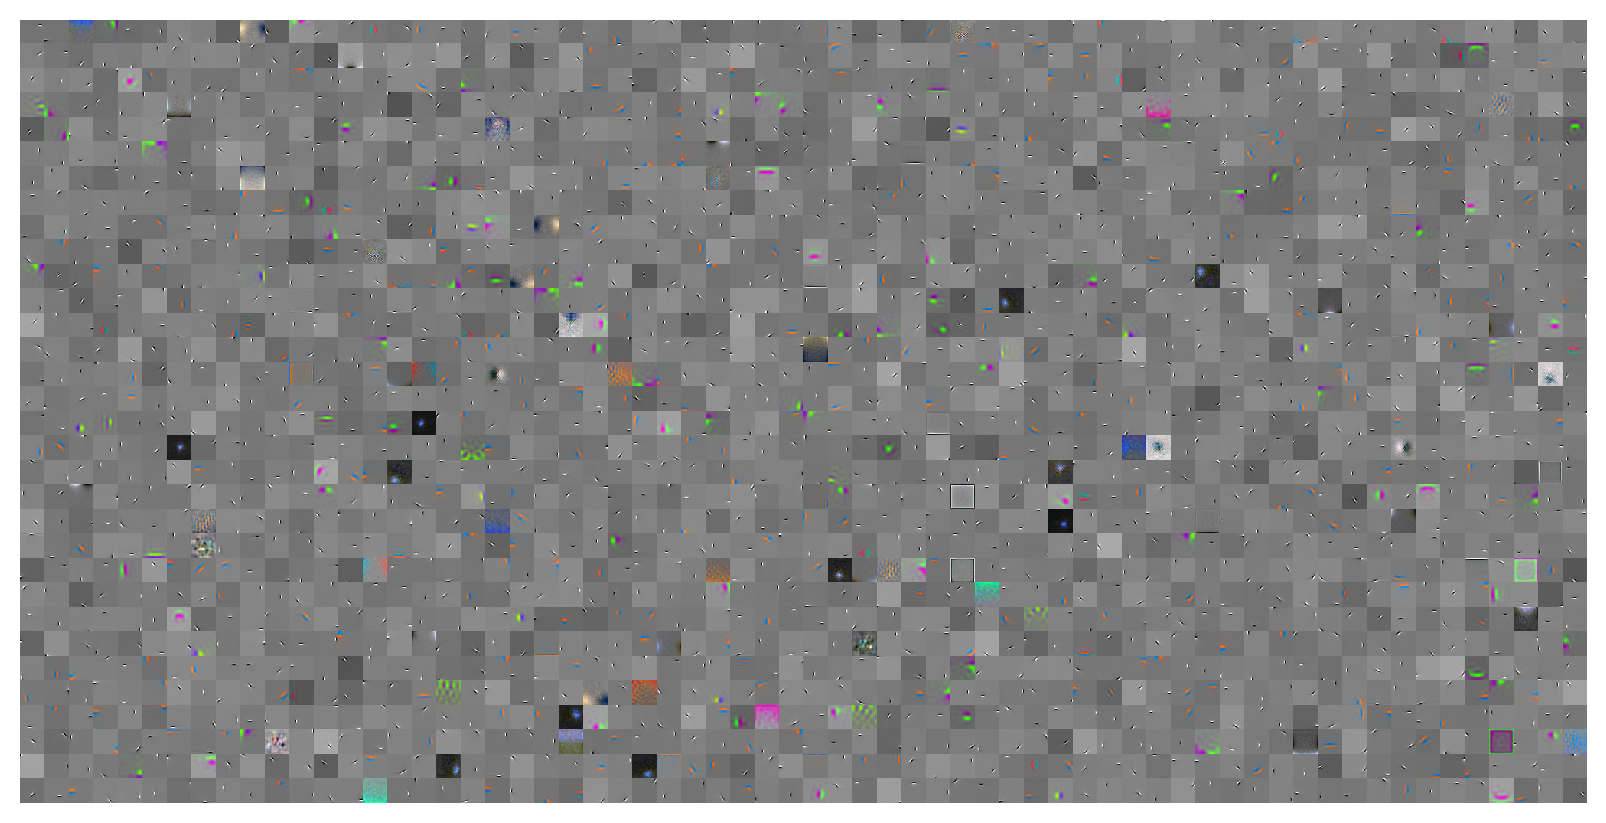

In [5]:
tr.model.show('p1');

In [8]:
tr.model.cfg.cfg_layers

{'g0': {'n_latents': 256,
  't_repeats': 1,
  'beta_outer': 128.0,
  'beta_inner': 1.0,
  'n_iters_inner': 1,
  'latent_act': 'logistic',
  'clamp_u': [7.0, 2.0],
  'clamp_du': [7.0, 3.0],
  'init_dist': 'normal',
  'init_scale': 0.0001,
  'stochastic': True,
  'fit_prior': True,
  't_train': 64,
  'seed': 0},
 'p1': {'prior_log_dist': 'uniform',
  'clamp_prior': -2.0,
  'n_latents': 2048,
  't_repeats': 1,
  'beta_outer': 96.0,
  'beta_inner': 1.0,
  'n_iters_inner': 1,
  'latent_act': None,
  'clamp_u': 4.5,
  'clamp_du': 7.0,
  'init_dist': 'normal',
  'init_scale': 0.0001,
  'stochastic': True,
  'fit_prior': True,
  't_train': 64,
  'seed': 0}}

In [9]:
np.exp(4.5)

90.01713130052181

In [10]:
output = tr.xtract_ftr(n_data_batches=1)

100%|███████████████████████████████████| 1/1 [00:05<00:00,  5.42s/it]


In [11]:
list(output)

['g0', 'p1', 'times']

In [17]:
state = output['p1']['state'][:, -1]
spks = output['p1']['samples'][:, -1]

state.shape, spks.shape

((200, 2048), (200, 2048))

In [16]:
(spks == 0).mean()

0.82651611328125

In [18]:
state

array([[-8.000004  , -7.2765007 , -8.000004  , ..., -8.000004  ,
        -1.7003627 , -7.9652653 ],
       [-4.905386  , -7.950346  , -7.7411985 , ..., -7.90532   ,
        -4.113594  , -8.000004  ],
       [-8.000004  , -8.000004  , -8.000004  , ..., -8.000004  ,
        -8.000004  , -1.3525968 ],
       ...,
       [-0.74131536, -8.000004  , -7.8326693 , ..., -8.000004  ,
        -0.39536715, -7.9897842 ],
       [-7.998725  , -7.994276  , -8.000004  , ..., -1.7055335 ,
        -0.42608356, -7.9878273 ],
       [-8.000004  , -8.000004  , -7.1276464 , ..., -0.5671034 ,
        -7.754218  ,  1.001647  ]], dtype=float32)

In [19]:
state.max()

3.0860877

In [21]:
np.ln(100)

AttributeError: module 'numpy' has no attribute 'ln'